# 训练目标

生成器 $f_\theta$ 接受噪声输入 $\epsilon$，输出生成样本 $\mathbf{x}=f_\theta(\epsilon)$。Drifting Models 训练的目标是让模型的预测去靠近漂移后的版本，漂移后的版本是在当前模型预测的基础上，加上一个漂移场 $\mathbf{V}_{p,q}$，然后再经过 stopgrad 操作，得到的一个固定的预测目标。漂移场 $\mathbf{V}_{p,q}$ 与数据分布 $p$ 和生成分布 $q$ 有关，指导模型生成结果改进的方向。

$$
\mathcal{L}=\mathbb{E}_\epsilon\left[||\underbrace{f_\theta(\epsilon)}_{模型预测}-\underbrace{\text{stopgrad}(f_\theta(\epsilon)+\mathbf{V}_{p,q_\theta}(f_\theta(\epsilon))}_{固定目标}||^2\right]
$$

这样的训练目标，写成损失函数代码如下：

In [1]:
import torch
import torch.nn.functional as F
from torch import nn, Tensor

def drifting_loss(gen: torch.Tensor, pos: torch.Tensor, compute_drift: callable):
    """Drifting loss: MSE(gen, stopgrad(gen + V))."""
    with torch.no_grad():
        V = compute_drift(gen, pos)
        target = (gen + V).detach()
    return F.mse_loss(gen, target)



# Mean-shift 漂移场

有了训练目标的形式之后，我们可以自己设计一种漂移场，只要满足 $p=q \implies \mathbf{V}=0$ 即可。这里是原文给出的 Mean-shift 漂移场，这种场基于 “吸引-排斥” 的思想。

具体定义为：
$$
\mathbf{V}_{p,q}(\mathbf{x}):=\mathbf{\color{blue}V}^{{\color{blue}+}}_q(\mathbf{x})-\mathbf{\color{orange}V}^{{\color{orange}-}}_q(\mathbf{x})
$$

其中

$$
\mathbf{\color{blue}V}^{{\color{blue}+}}_{{q}}(\mathbf{x}):=\frac{1}{Z_p}\mathbb{E}_p[k(\mathbf{x},{\color{blue}{\mathbf{y}^+}})({\color{blue}{\mathbf{y}^+}}-\mathbf{x})], \quad
\mathbf{\color{orange}V}^{{\color{orange}-}}_{{q}}(\mathbf{x}):=\frac{1}{Z_q}\mathbb{E}_q[k(\mathbf{x},{\color{orange}{\mathbf{y}^-}})({\color{orange}{\mathbf{y}^-}}-\mathbf{x})]
$$

这里的 $Z$ 是归一化项：

$$
Z_p:=\mathbb{E}_{{\color{blue}{y^+}}\sim p}[k(\mathbf{x},{\color{blue}\mathbf{y}^+})], \quad
Z_q:=\mathbb{E}_{{\color{orange}{y^-}}\sim q}[k(\mathbf{x},{\color{orange}\mathbf{y}^-})]
$$

将 $\mathbf{V}^+_p,\mathbf{V}^-_q$ 代入后，得到：

$$
\mathbf{V}_{p,q}(\mathbf{x}):=\frac{1}{Z_pZ_q}\mathbb{E}_{p,q}[k(x,{\color{blue}{\mathbf{y}^+}})k(x,{\color{orange}{\mathbf{y}^-}})({\color{blue}{\mathbf{y}^+}}-{\color{orange}{\mathbf{y}^-}})]
$$

---

# 实际实现（批次归一化的蒙特卡洛估计）

实际训练中，使用 mini-batch 来近似上面这个期望，即：

$$
\mathbf{V}(\mathbf{x}):=\mathbb{E}[K_B(x,{\color{blue}{\mathbf{y}^+}})K_B(x,{\color{orange}{\mathbf{y}^-}})({\color{blue}{\mathbf{y}^+}}-{\color{orange}{\mathbf{y}^-}})]
$$

其中 $K_B$ 是批次归一化的核函数，即核函数 $k$ 在一个批次 $B$ 内再归一化。

显然，当 $p=q$ 时，有 $\mathbf{y}^+-\mathbf{y}^-=0$，从而 $\mathbf{V}=0$，这样构建的漂移场能够满足反对称性的要求。实际中，我们在每个 mini-batch 上进行蒙特卡洛估计。

选用的核函数是 $k(\mathbf{x,y})=\exp(-||\mathbf{x-y}||/\tau)$，然后 $K_B$ 在此基础上再对 $\mathbf{x,y}$ 在 batch 内进行批次归一化，实际发现这样能够提升一些性能。

以下是参考实现。


In [2]:
def compute_drift(gen: Tensor, pos: Tensor, temp: float = 0.05):
    """
    Compute drift field V with attention-based kernel.
    
    Args:
        gen: Generated samples [G, D]
        pos: Data samples [P, D]
        temp: Temperature for softmax kernel
    
    Returns:
        V: Drift vectors [G, D]
    """
    targets = torch.cat([gen, pos], dim=0)
    G = gen.shape[0]

    dist = torch.cdist(gen, targets)
    dist[:, :G].fill_diagonal_(1e6)  # mask self
    kernel = (-dist / temp).exp() # unnormalized kernel

    normalizer = kernel.sum(dim=-1, keepdim=True) * kernel.sum(dim=-2, keepdim=True)    # 对两个维度都进行归一化，实际发现有一定性能提升
    normalizer = normalizer.clamp_min(1e-12).sqrt()
    normalized_kernel = kernel / normalizer

    # gen（kernel[:, G:]）自己作为负样本，pos（kernel[:, :G）作为正样本
    pos_coeff = normalized_kernel[:, G:] * normalized_kernel[:, :G].sum(dim=-1, keepdim=True)
    pos_V = pos_coeff @ targets[G: ]
    neg_coeff = normalized_kernel[:, :G] * normalized_kernel[:, G:].sum(dim=-1, keepdim=True)
    neg_V = neg_coeff @ targets[: G]
    
    return pos_V - neg_V


# 漂移场可视化

我们来看看随机初始化的分布 $q$ 对应的漂移场是什么样的。

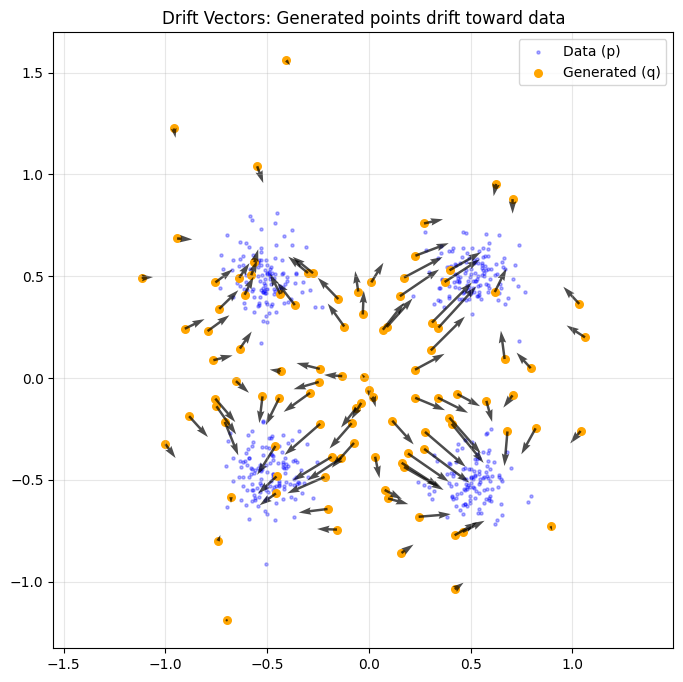

In [3]:
import matplotlib.pyplot as plt

# （高斯）随机一些生成结果
gen_test = torch.randn(100, 2) * 0.5

# 目标数据分布：四个中心的高斯分布
centers = torch.tensor([[-0.5, -0.5], [-0.5, 0.5], [0.5, -0.5], [0.5, 0.5]])
idx = torch.randint(0, 4, (500,))
pos_test = centers[idx] + torch.randn(500, 2) * 0.1

# 计算漂移场
drift_test = compute_drift(gen_test, pos_test, temp=0.2)

# 绘图
plt.figure(figsize=(8, 8))
plt.scatter(pos_test[:, 0], pos_test[:, 1], s=5, alpha=0.3, c='blue', label='Data (p)')
plt.scatter(gen_test[:, 0], gen_test[:, 1], s=30, c='orange', label='Generated (q)')
plt.quiver(gen_test[:, 0], gen_test[:, 1], drift_test[:, 0], drift_test[:, 1],
           scale=3, color='black', alpha=0.7, width=0.004)
plt.legend()
plt.title('Drift Vectors: Generated points drift toward data')
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.show()

# 经典分布训练

我们用 checkerboard 和 swiss roll 这两个经典的简单 2D 分布，来介绍一下 Drifting Models 的训练过程。

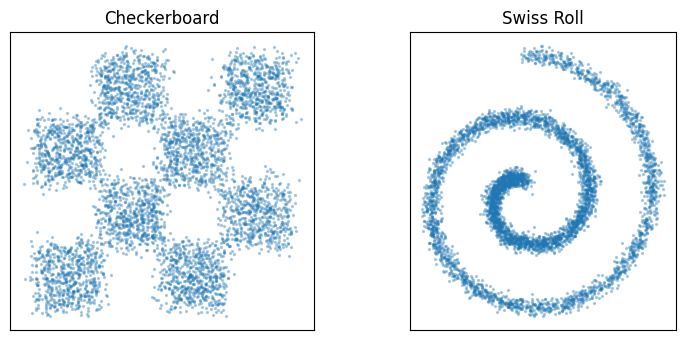

In [4]:
# 首先可视化一下 checkerboard, swiss toll 这两个 2D 分布
import math

def sample_checkerboard(n: int, noise: float = 0.05, seed: int | None = None) -> torch.Tensor:
    g = torch.Generator().manual_seed(seed) if seed is not None else None
    b = torch.randint(0, 2, (n,), generator=g)
    i = torch.randint(0, 2, (n,), generator=g) * 2 + b
    j = torch.randint(0, 2, (n,), generator=g) * 2 + b
    u = torch.rand(n, generator=g)
    v = torch.rand(n, generator=g)
    pts = torch.stack([i + u, j + v], dim=1) - 2.0
    pts = pts / 2.0
    if noise > 0:
        pts = pts + noise * torch.randn(pts.shape, generator=g)
    return pts


def sample_swiss_roll(n: int, noise: float = 0.03, seed: int | None = None) -> torch.Tensor:
    g = torch.Generator().manual_seed(seed) if seed is not None else None
    u = torch.rand(n, generator=g)
    t = 0.5 * math.pi + 4.0 * math.pi * u
    pts = torch.stack([t * torch.cos(t), t * torch.sin(t)], dim=1)
    pts = pts / (pts.abs().max() + 1e-8)
    if noise > 0:
        pts = pts + noise * torch.randn(pts.shape, generator=g)
    return pts


# quick look
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
for ax, (name, sampler) in zip(axes, [("Checkerboard", sample_checkerboard), ("Swiss Roll", sample_swiss_roll)]):
    pts = sampler(5000).numpy()
    ax.scatter(pts[:, 0], pts[:, 1], s=2, alpha=0.3)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(name)
plt.tight_layout()
plt.show()

In [10]:
# ============================================================
# Training Loop for Toy 2D
# ============================================================
from functools import partial
from tqdm.auto import tqdm

class MLP(nn.Module):
    """MLP: noise -> output. 3 hidden layers with SiLU."""
    def __init__(self, in_dim=32, hidden=256, out_dim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, out_dim),
        )
    def forward(self, z):
        return self.net(z)


def plot(sampler, model, step: int, num_sample: int = 5000, in_dim: int = 32):
    gt = sampler(num_sample).numpy()
    
    noise = torch.randn(num_sample, in_dim)
    with torch.inference_mode():
        vis = model(noise).to('cpu').numpy()
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3.5))
    ax1.scatter(gt[:, 0], gt[:, 1], s=2, alpha=0.3, c='black')
    ax1.set_title('Target'); ax1.set_aspect('equal'); ax1.axis('off')
    ax2.scatter(vis[:, 0], vis[:, 1], s=2, alpha=0.3, c='tab:orange')
    ax2.set_title(f'Generated (step {step})'); ax2.set_aspect('equal'); ax2.axis('off')
    plt.tight_layout()
    plt.show()

def train(sampler, steps: int = 2000, data_batch_size: int = 2048, gen_batch_size: int = 2048, lr: float = 1e-3, temp: float = 0.05,
    in_dim: int = 32, hidden: int = 256,  plot_every: int = 500, seed: int = 0, device: str = 'cpu'
):
    torch.manual_seed(seed)
    model = MLP(in_dim, hidden, 2).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    loss_history = []
    ema = None
    pbar = tqdm(range(1, steps + 1))
    for step in pbar:
        pos = sampler(data_batch_size).to(device)
        noise = torch.randn(gen_batch_size, in_dim).to(device)
        gen = model(noise)
        
        loss = drifting_loss(gen, pos, compute_drift=partial(compute_drift, temp=temp))
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        loss_history.append(loss.item())
        ema = loss.item() if ema is None else 0.96 * ema + 0.04 * loss.item()
        
        pbar.set_postfix(loss=f"{ema:.2e}")
        
        if step == 1 or step % plot_every == 0:
            plot(sampler, model, step, num_sample=5000, in_dim=in_dim)
        
    return model, loss_history


Training on Swiss Roll...


  0%|          | 0/2000 [00:00<?, ?it/s]

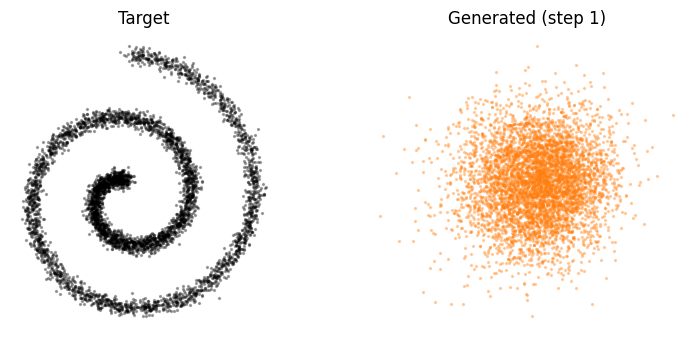

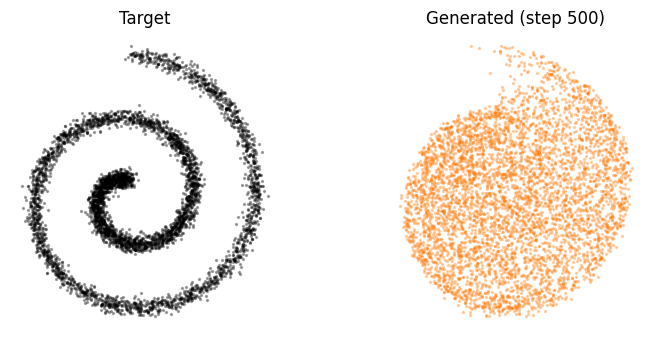

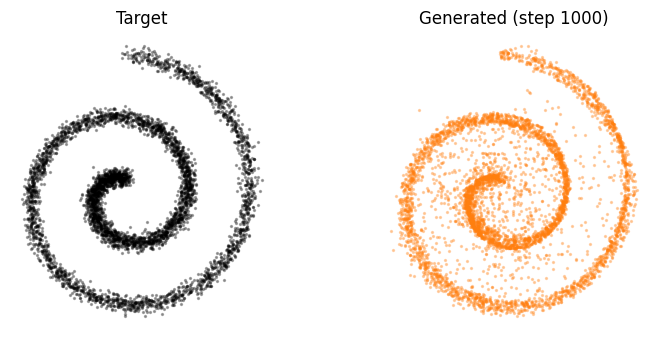

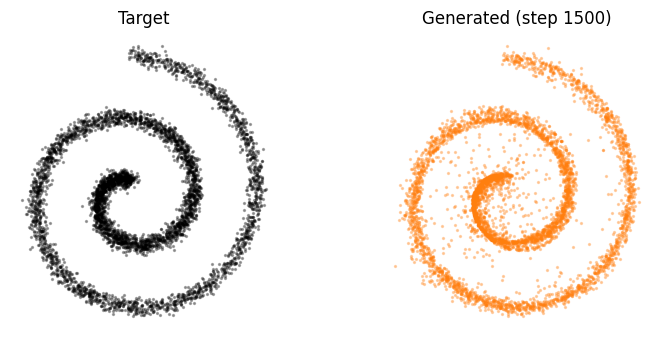

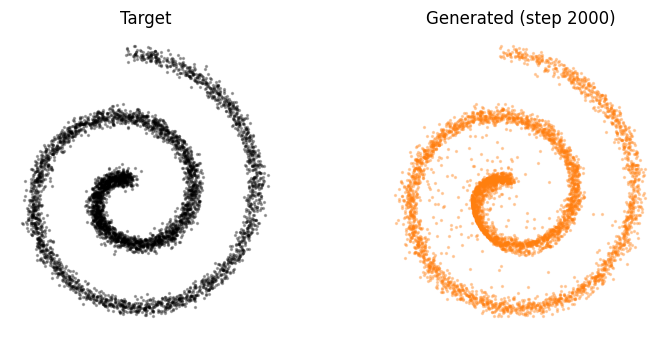

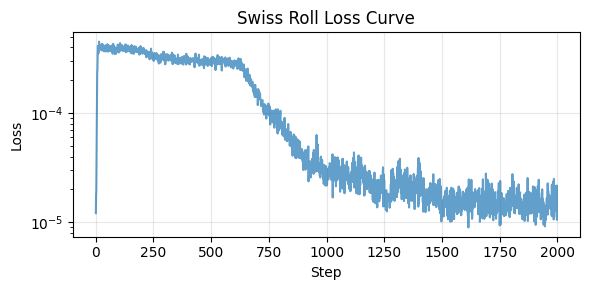

In [11]:
# 训练 swiss roll 分布

print("Training on Swiss Roll...")
model_swiss, loss_swiss = train(sample_swiss_roll, steps=2000, lr=1e-3, temp=0.05, device='cpu')

plt.figure(figsize=(6, 3))
plt.plot(loss_swiss, alpha=0.7)
plt.xlabel('Step'); plt.ylabel('Loss'); plt.title('Swiss Roll Loss Curve')
plt.yscale('log'); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()



Training on Checkerboard...


  0%|          | 0/2000 [00:00<?, ?it/s]

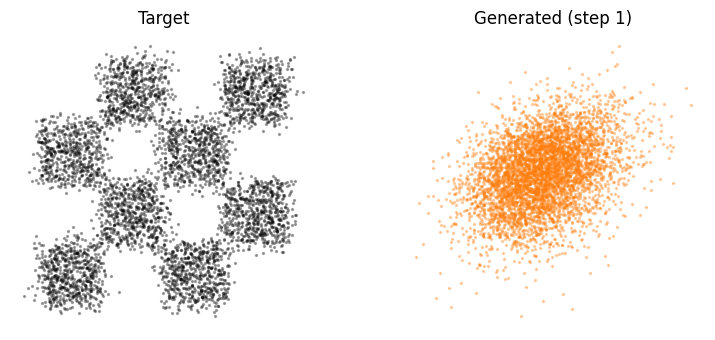

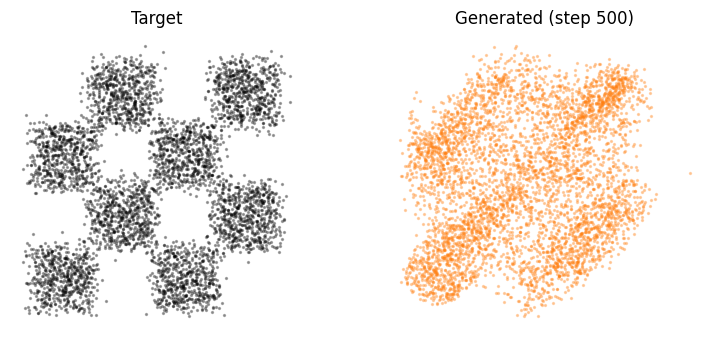

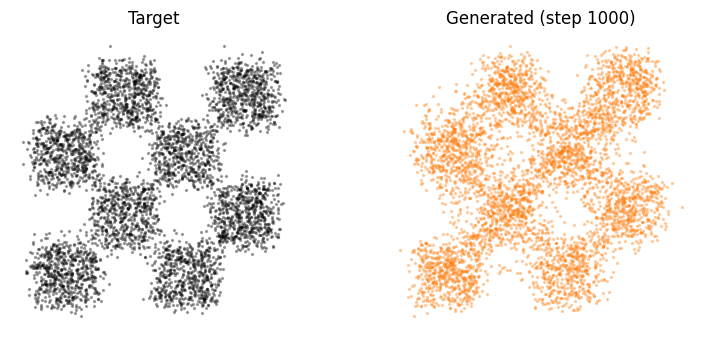

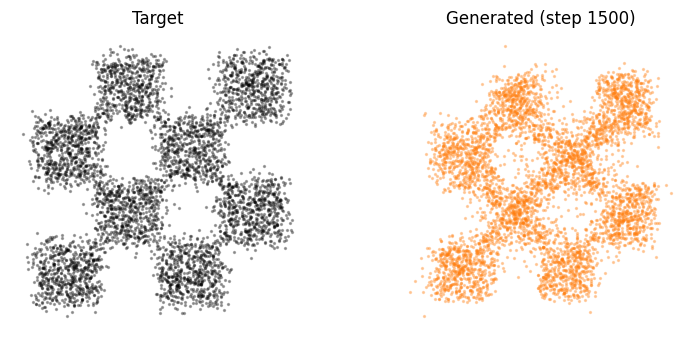

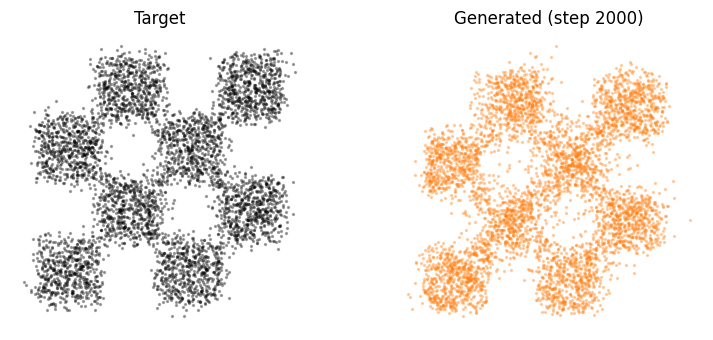

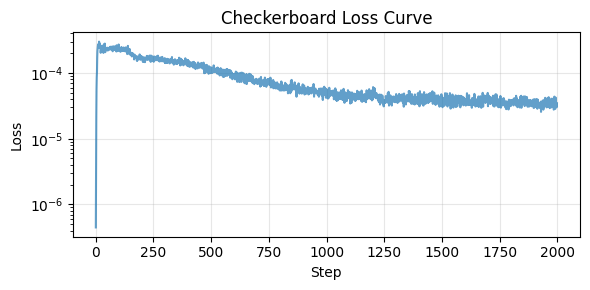

In [12]:
# 训练 checkerboard 分布

print("\nTraining on Checkerboard...")
model_checker, loss_checker = train(sample_checkerboard, steps=2000, lr=1e-3, temp=0.05)

plt.figure(figsize=(6, 3))
plt.plot(loss_checker, alpha=0.7)
plt.xlabel('Step'); plt.ylabel('Loss'); plt.title('Checkerboard Loss Curve')
plt.yscale('log'); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()